In [37]:
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [38]:
from randomness import *
from simulation_exact import *
from utils import *
from data_analysis import *
from main import *
import numpy as np
import warnings
import matplotlib.pyplot as plt
from matplotlib.collections import LineCollection
from matplotlib.colors import Normalize
from joblib import Parallel, delayed
from sklearn.metrics import accuracy_score
warnings.filterwarnings("ignore")
seed = 42
np.random.seed(seed)
rng = np.random.default_rng(seed)

In [39]:
def generate_data_d(n, mu1, mu2, rng, sigma = [1.0, 1.0], d=1):
    X1 = rng.normal(loc=mu1, scale=sigma[1], size=(n[1], d))
    X2 = rng.normal(loc=mu2, scale=sigma[0], size=(n[0], d))
    X = np.vstack([X1, X2])
    y = np.concatenate([
        -1 * np.ones(n[1]),
        np.ones(n[0])
    ])

    v = np.ones(n[0]+n[1])

    return X, y, v

In the block below, start by setting the parameters for the learning model  (lines 1-10 in block below)

experiments: (two blocks down )

1. to run the expirement for the same sample while changing mu_1 - mu_2, <br>
    remove the comments in lines 12 and 17 <br>
    comment line 16 <br>
    set T = 1 <br>

2. to run the expirement for the different samples and averaging over each T samples , <br>
    comments  lines 12 and 17 <br>
    remove comment line 16 <br>
    set T to be number of samples to be drawn per mu (line 12) <br>
 
In both cases you can choose parameters in lines 11-13, in the block below: <br>
    ds:= different dimensions to run the expierments on (line 11) <br>
    mus:= different mus to run the experiments on, where one distrbution has mean mu and the other has -mu (line 13)
    

In [40]:
# 1. choose parameters 
n_pos = 50 # number of data points in a sample with label 1
n_neg = 50 # number of data points in a sample with label -1
n = [n_pos, n_neg]
sigma_pos = 1.0 # data sd for generating process 
sigma_neg = 1.0 # data sd for generating process 
sigma = [sigma_pos , sigma_neg] 
# ---------------------------------
use_loss = 'hinge' #'log' or 'hinge' or 'squared_hinge' 
sigma_loss = 1.0 
c = 1.0 # choose c without scaling 
show_plots = False # set to True to see plots of the binary search
is_throw = True # set to True to throw out points outside margin --> only when loss is lipschitz. 
#TODO: add is throw to outside_inside function 
k = None # if none will be set based on data max norm
k_coef = 1.0 # coefficient to multiply k with
fit_intercept = True # whether to fit intercept in SVM model
# ---------------------------------
ds = [2, 4, 8, 16, 32, 64] # dimensions to run experiments on
T = 50  # number of trials
mus = np.linspace(1.0, 0.0, 31) # different mus to run the experiments on


In [43]:
# 3. run exact simulation
# returns df with cols "agent" | "true_v" | "critical_v" | "allocation" | "welfare" | "utility"
# utility = welfare - payment
# welfare = allocation * true_v
# critical_v = payment 

def compute_metrics_d(d):#, k = None):
    # num_payers = np.zeros(len(mus))
    num_payers = {i: [] for i in range(len(mus))}
    sum_payments = {i: [] for i in range(len(mus))}
    acc = {i: [] for i in range(len(mus))}
    prc_relevant = {i: [] for i in range(len(mus))}
    sum_welfare = {i: [] for i in range(len(mus))}
    sum_utility = {i: [] for i in range(len(mus))}
    accuracy_validation = {i: [] for i in range(len(mus))}

    for _ in range(T):
        #x, y, v = generate_data_d(n, mus[0], -mus[0], rng, sigma, d)
        for i, mu in enumerate(mus):
            x, y, v = generate_data_d(n, mu, -mu, rng, sigma, d)
            n_val = [int(n_pos * 0.2), int(n_neg * 0.2)]
            x_val, y_val, v_val = generate_data_d(n_val, mu, -mu, rng, sigma, d)
            #x_updated = update_data(x, y, mu, -mu)
            df_exact, svm_model = run_exact(x, y, v, c, use_loss, sigma_loss=sigma_loss, plot=show_plots, 
                                    is_throw=is_throw, k=k, k_coef=k_coef, fit_intercept=fit_intercept)
    
            acc[i].append(svm_model.score(x,y,sample_weight = v))
            num_payers[i].append((df_exact['critical_v'] > 0).sum())
            sum_payments[i].append(df_exact['critical_v'].sum())
            prc_relevant[i].append( len(df_exact[df_exact['is_relevant'] == 1]) / len(df_exact))
            sum_welfare[i].append(df_exact['welfare'].sum())
            sum_utility[i].append(df_exact['utility'].sum())    
            accuracy_validation[i].append(svm_model.score(x_val,y_val, sample_weight = v_val))


    return d, {
        "num_payers": num_payers,
        "acc": acc,
        "sum_payments": sum_payments,
        "prc_relevant": prc_relevant,
        "sum_welfare": sum_welfare,
        "sum_utility": sum_utility,
        "accuracy_validation": accuracy_validation
    }


In [ ]:
results = Parallel(n_jobs=-1, backend="loky")(
    delayed(compute_metrics_d)(d) for d in ds
)

results = dict(results) # map from d to metrics dict

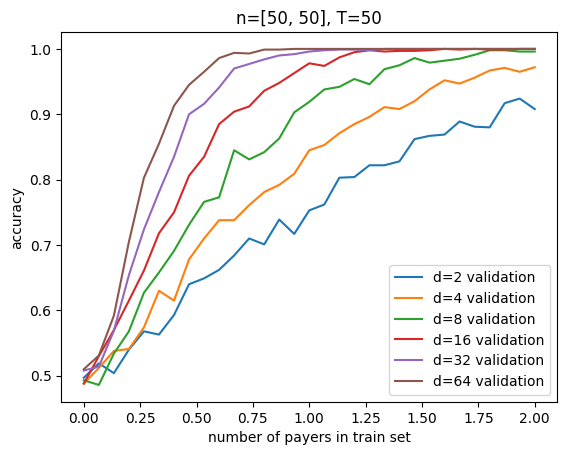

In [55]:
for d in results.keys():
    num_payers = results[d]["num_payers"]
    acc = results[d]["acc"]
    sum_payments = results[d]["sum_payments"]
    prc_relevant = results[d]["prc_relevant"]
    sum_welfare = results[d]["sum_welfare"]
    sum_utility = results[d]["sum_utility"]
    accuracy_validation = results[d]["accuracy_validation"]

    mean_num_payers = np.array([np.mean(num_payers[i]) for i in range(len(mus))])
    mean_sum_payments = np.array([np.mean(sum_payments[i]) for i in range(len(mus))])
    mean_accuracy_train = np.array([np.mean(acc[i]) for i in range(len(mus))])
    mean_prc_relevant = np.array([np.mean(prc_relevant[i]) for i in range(len(mus))])
    mean_sum_welfare = np.array([np.mean(results[d]["sum_welfare"][i]) for i in range(len(mus))])
    mean_sum_utility = np.array([np.mean(results[d]["sum_utility"][i]) for i in range(len(mus))])
    mean_accuracy_validation = np.array([np.mean(accuracy_validation[i]) for i in range(len(mus))])

    sd_num_payers = np.array([np.std(num_payers[i]) for i in range(len(mus))])
    sd_sum_payments = np.array([np.std(sum_payments[i]) for i in range(len(mus))])
    sd_welfare = np.array([np.std(sum_welfare[i]) for i in range(len(mus))])
    sd_utility = np.array([np.std(sum_utility[i]) for i in range(len(mus))])

    plt.plot(2* mus, mean_accuracy_validation, label=f"d={d} validation")
    #plt.plot(2* mus, mean_accuracy_train, label=f"d={d} train")

plt.ylabel("accuracy")
plt.xlabel("number of payers in train set")
plt.legend()
# plt.grid(True)
plt.title(f"n={n}, T={T}")
plt.show()

TODO: <br>
<ul>
     <li>create micro notebook </li>
     <li>check for beta data </li>
     <li> validation set </li>
     <li> welfare metrics </li>
</ul>

